In [20]:
import pandas as pd
import matplotlib.pyplot as plt

#Am ales un set de date de la un senzor de Temperatura. Acesta include atat date reale, cat si
#data generate artificial (anomalii) pentru a simula o gama larga de conditii.

df = pd.read_csv("synthetic_iot_dataset_challenging.csv")

print("Primele 5 intrari in csv: \n",df.head())
print("\nTipuri de date: \n")
df.info()
print("\nStatistici descriptive: \n",df.describe())




Primele 5 intrari in csv: 
   Device_ID  Temperature  Humidity  Battery_Level  Anomaly
0   DHT11_B    -0.555734 -0.157264       0.377032        0
1   DHT11_A    -0.266879 -0.086229      -0.217410        0
2   DHT11_B     0.128544  0.041150       0.090479        0
3   DHT11_D    -1.001516 -0.320621      -0.705341        0
4   DHT11_D     0.311015  0.115365       0.807002        0

Tipuri de date: 

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Device_ID      3000 non-null   str    
 1   Temperature    3000 non-null   float64
 2   Humidity       3000 non-null   float64
 3   Battery_Level  3000 non-null   float64
 4   Anomaly        3000 non-null   int64  
dtypes: float64(3), int64(1), str(1)
memory usage: 117.3 KB

Statistici descriptive: 
        Temperature     Humidity  Battery_Level      Anomaly
count  3000.000000  3000.000000    3000.000000  3

In [21]:
print("\nNumar valori lipsa = ",df.isnull().sum())


Numar valori lipsa =  Device_ID        0
Temperature      0
Humidity         0
Battery_Level    0
Anomaly          0
dtype: int64


In [23]:
df['Timestamp'] = pd.date_range(start='2026-03-04', periods=len(df), freq='1Min')
#am adaugat artifical un timestamp pentru fiecare intrare a senzorului in setul de date

In [24]:
df.head()

,Device_ID,Temperature,Humidity,Battery_Level,Anomaly,Timestamp
0,DHT11_B,-0.555734,-0.157264,0.377032,0,2026-03-04 00:00:00
1,DHT11_A,-0.266879,-0.086229,-0.217410,0,2026-03-04 00:01:00
2,DHT11_B,0.128544,0.041150,0.090479,0,2026-03-04 00:02:00
3,DHT11_D,-1.001516,-0.320621,-0.705341,0,2026-03-04 00:03:00
4,DHT11_D,0.311015,0.115365,0.807002,0,2026-03-04 00:04:00


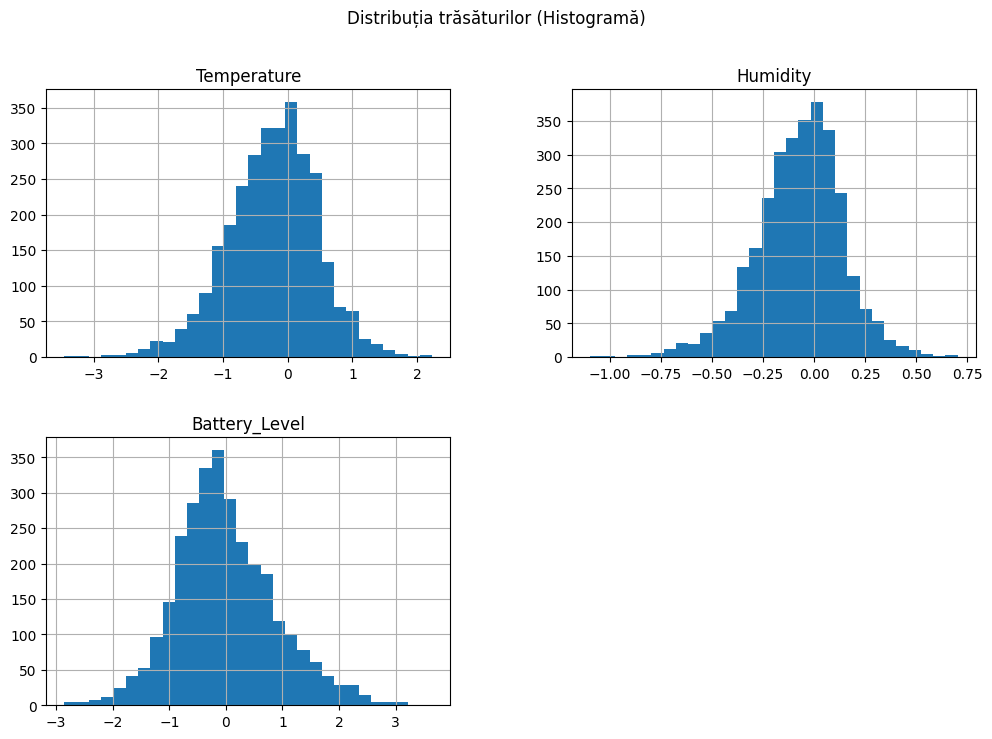

In [27]:
df[['Temperature', 'Humidity', 'Battery_Level']].hist(bins=30, figsize=(12, 8))
plt.suptitle('Distribuția trăsăturilor (Histogramă)')
plt.show()

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

#Partea de Feature Engineering
# Sortam pentru a asigura ordinea cronologică / dispozitiv
df = df.sort_values(by=['Device_ID', 'Timestamp'])

# Cream context temporal (Rolling Mean & Std)
df['Temp_Rolling_Mean'] = df.groupby('Device_ID')['Temperature'].transform(lambda x: x.rolling(window=5, min_periods=1).mean())
df['Temp_Rolling_Std'] = df.groupby('Device_ID')['Temperature'].transform(lambda x: x.rolling(window=5, min_periods=1).std()).fillna(0)

In [31]:
#Foloseim label encoder pentru a transforma id-urile senzorilor in index-uri parsabile pentru model

le = LabelEncoder()
df['Device_ID_Encoded'] = le.fit_transform(df['Device_ID'])

In [32]:
features = ['Temperature', 'Humidity', 'Battery_Level', 'Temp_Rolling_Mean', 'Temp_Rolling_Std', 'Device_ID_Encoded']
X = df[features]
y_true = df['Anomaly']

In [33]:
# 'contamination' reprezintă proporția estimată de anomalii
model = IsolationForest(n_estimators=100, contamination=0.17, random_state=42)
model.fit(X)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.17
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [35]:
y_pred = model.predict(X)
df['Detected_Anomaly'] = [1 if x == -1 else 0 for x in y_pred]


--- 7. Evaluare ---
Matricea de confuzie:



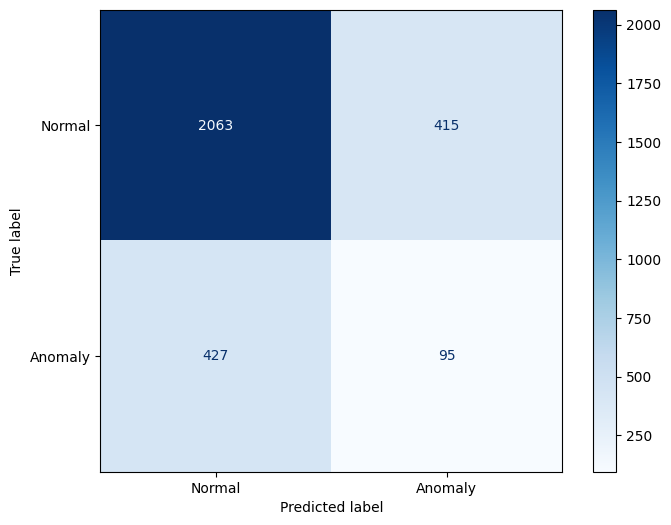


Raport de clasificare:

              precision    recall  f1-score   support

           0       0.83      0.83      0.83      2478
           1       0.19      0.18      0.18       522

    accuracy                           0.72      3000
   macro avg       0.51      0.51      0.51      3000
weighted avg       0.72      0.72      0.72      3000



In [40]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# 1. Calculăm matricea de confuzie
cm = confusion_matrix(y_true, df['Detected_Anomaly'])

# 2. Definim vizualizarea
# Setează display_labels conform claselor tale (0 = Normal, 1 = Anomaly)
disp_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Anomaly'])

# 3. Plotăm
print("\n--- 7. Evaluare ---")
print("Matricea de confuzie:\n")
fig, ax = plt.subplots(figsize=(8, 6))
disp_cm.plot(ax=ax, cmap='Blues')
plt.show()

# 4. Afișăm raportul
print("\nRaport de clasificare:\n")
print(classification_report(y_true, df['Detected_Anomaly']))

Rezultatele (Recall/Precision scăzute) sunt normale pentru un model nesupervizat <br>
precum Isolation Forest pe acest set de date. <br>

1. Isolation Forest caută "outliers" (puncte izolate în spațiul 3D al datelor),
   dar nu înțelege logica din spatele etichetei 'Anomaly'. <br>
2. IoT-ul conține adesea "zgomot" care nu este anomalie, ceea ce generează alarme false. <br>
3. Soluție: Dacă dorim îmbunătățirea metricilor, trebuie să trecem la un model supervizat  <br>
   (ex: RandomForest), care să învețe pattern-urile specifice din coloana 'Anomaly'. <br>



--- Raport de clasificare (pe setul de test) ---
              precision    recall  f1-score   support

           0       0.87      0.95      0.91       487
           1       0.64      0.39      0.48       113

    accuracy                           0.84       600
   macro avg       0.75      0.67      0.70       600
weighted avg       0.83      0.84      0.83       600


--- Evaluare Model Supervizat (Random Forest) ---
Matricea de confuzie:
 [[462  25]
 [ 69  44]]


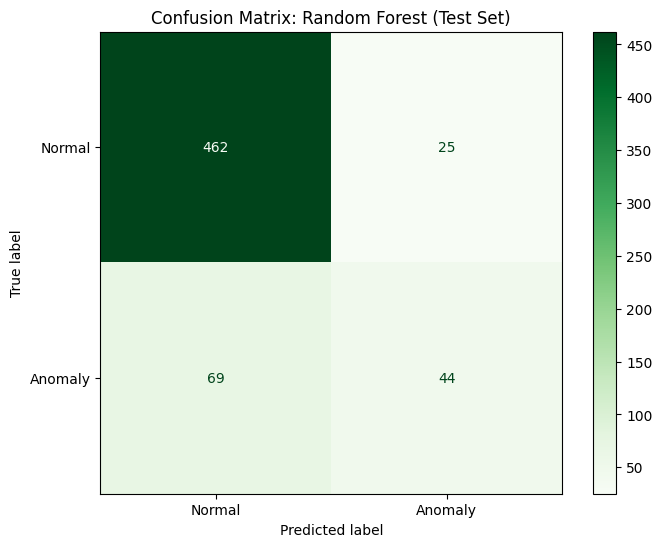

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

#Facem split- ul de date 80 % pentru antrenare 20 % pentru testare
X_train, X_test, y_train, y_test = train_test_split(X, y_true, test_size=0.2, random_state=42)

# Antrenam modelul
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


y_pred = model.predict(X_test)


print("\n--- Raport de clasificare (pe setul de test) ---")
print(classification_report(y_test, y_pred))


cm = confusion_matrix(y_test, y_pred)


print("\n--- Evaluare Model Supervizat (Random Forest) ---")
print("Matricea de confuzie:\n", cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Anomaly'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Greens')
plt.title("Confusion Matrix: Random Forest (Test Set)")
plt.show()